### Модуль выбора признаков для задачи распознавания утомления

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

def load_full_features(npz_path):
    """
    Загружает акустические признаки и метки классов из .npz файла.

    Аргументы:
        npz_path (str): Путь к .npz файлу, содержащему массивы признаков.

    Возвращает:
        temporals (np.ndarray): Массив временных признаков формы (n_samples, 101, 43).
        jitters (np.ndarray): Вектор признака джиттера длины (n_samples,).
        shimmers (np.ndarray): Вектор признака шиммера длины (n_samples,).
        labels (np.ndarray): Вектор меток классов длины (n_samples,).
    """
    data = np.load(npz_path, allow_pickle=True)
    temporals = data['temporals']      # (n_samples, 101, 43)
    jitters = data['jitters']          # (n_samples,)
    shimmers = data['shimmers']        # (n_samples,)
    labels = data['labels']            # (n_samples,)
    
    print(f"Загружено {len(temporals)} образцов")
    print(f"Форма временных признаков: {temporals.shape}")
    print(f"Распределение классов: {np.bincount(labels)}")
    
    return temporals, jitters, shimmers, labels


def analyze_features(temporals, labels, top_n=20):
    """
    Анализирует временные признаки с тремя подходами:
    - Вычисление F-отношения (ANOVA) для оценки различий между классами.
    - Оценка важности признаков с помощью Random Forest.
    - Поиск пар сильно коррелированных признаков.

    Аргументы:
        temporals (np.ndarray): Массив временных признаков (n_samples, 101, 43).
        labels (np.ndarray): Вектор меток классов длины (n_samples,).
        top_n (int, по умолчанию 20): Число топ-признаков для вывода по каждому критерию.

    Возвращает:
        f_scores (pd.DataFrame): Таблица с результатами ANOVA (F-значения и p-value) для каждого признака.
        rf_importance (pd.DataFrame): Таблица с важностями признаков по Random Forest.
        feature_names (list of str): Список названий всех признаков (длина 43).
        X_mean (np.ndarray): Усреднённая матрица признаков (n_samples, 43).
    """
    # Усредняем признаки по времени
    X_mean = np.mean(temporals, axis=1)  # (n_samples, 43)

    # Названия признаков
    feature_names = (
        [f'MFCC_{i}' for i in range(13)] +
        [f'Delta_{i}' for i in range(13)] +
        [f'Delta2_{i}' for i in range(13)] +
        ['F0', 'RMS', 'HNR', 'ZCR']
    )
    
    # 1. F-отношение (ANOVA)
    selector = SelectKBest(f_classif, k=top_n)
    selector.fit(X_mean, labels)
    
    f_scores = pd.DataFrame({
        'feature': feature_names,
        'f_score': selector.scores_,
        'p_value': selector.pvalues_
    }).sort_values('f_score', ascending=False)
    
    print("\n" + "="*60)
    print("ТОП-20 ПРИЗНАКОВ ПО F-ОТНОШЕНИЮ (ANOVA)")
    print("="*60)
    for i, row in f_scores.head(top_n).iterrows():
        print(f"{row['feature']:20} F={row['f_score']:.2f} (p={row['p_value']:.2e})")
    
    # 2. Важность признаков по Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_mean, labels)
    
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*60)
    print("ТОП-20 ПРИЗНАКОВ ПО RANDOM FOREST")
    print("="*60)
    for i, row in rf_importance.head(top_n).iterrows():
        print(f"{row['feature']:20} важность={row['importance']:.4f}")
    
    # 3. Корреляционный анализ
    corr_matrix = np.corrcoef(X_mean.T)
    
    # Находим пары сильно коррелированных признаков (>0.95)
    high_corr = []
    for i in range(len(feature_names)):
        for j in range(i+1, len(feature_names)):
            if abs(corr_matrix[i, j]) > 0.95:
                high_corr.append((feature_names[i], feature_names[j], corr_matrix[i, j]))
    
    if high_corr:
        print("\n" + "="*60)
        print("СИЛЬНО КОРРЕЛИРОВАННЫЕ ПРИЗНАКИ (>0.95)")
        print("="*60)
        for f1, f2, corr in high_corr[:15]:
            print(f"{f1} <-> {f2}: {corr:.3f}")
    else:
        print("\nСильно коррелированных признаков не обнаружено")
    
    return f_scores, rf_importance, feature_names, X_mean


def select_optimal_features(temporals, labels, f_scores, rf_importance, 
                            f_threshold=50, corr_threshold=0.95, 
                            top_n_combined=12):
    """
    Отбирает оптимальный поднабор признаков на основе комбинации F-отношения и важности в Random Forest.

    Аргументы:
        temporals (np.ndarray): Массив временных признаков (n_samples, 101, 43).
        labels (np.ndarray): Вектор меток классов длины (n_samples,).
        f_scores (pd.DataFrame): Результаты анализа ANOVA.
        rf_importance (pd.DataFrame): Важности признаков по Random Forest.
        f_threshold (float, по умолчанию 50): Пороговое значение для F-отношения при отборе (не используется в этом коде).
        corr_threshold (float, по умолчанию 0.95): Порог корреляции для удаления избыточных признаков (не используется в этом коде).
        top_n_combined (int, по умолчанию 12): Сколько лучших признаков отобрать на основании комбинированного рейтинга.

    Возвращает:
        selected_features (list of str): Список названий выбранных признаков.
    """
    # Комбинируем результаты двух методов
    combined = pd.merge(f_scores, rf_importance, on='feature')
    combined['score'] = (combined['f_score'] / combined['f_score'].max() + 
                          combined['importance'] / combined['importance'].max()) / 2
    combined = combined.sort_values('score', ascending=False)
    
    # Отбираем топ-N
    selected = combined.head(top_n_combined).copy()
    
    print("\n" + "="*60)
    print(f"ОПТИМАЛЬНЫЕ ПРИЗНАКИ (топ-{top_n_combined} по комбинированному рейтингу)")
    print("="*60)
    for i, row in selected.iterrows():
        print(f"{row['feature']:20} F={row['f_score']:.2f} | важность={row['importance']:.4f}")
    
    return selected['feature'].tolist()


def plot_feature_importance(f_scores, rf_importance, top_n=15):
    """
    Визуализирует важность признаков по результатам ANOVA и по Random Forest.

    Аргументы:
        f_scores (pd.DataFrame): Таблица с результатами ANOVA (F-значения и p-value) для каждого признака.
        rf_importance (pd.DataFrame): Таблица с важностями признаков по Random Forest.
        top_n (int, по умолчанию 15): Сколько топ-признаков визуализировать с каждого метода.

    Возвращает:
        график
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # F-отношение (ANOVA)
    top_f = f_scores.head(top_n)
    axes[0].barh(top_f['feature'], top_f['f_score'], color='steelblue')
    axes[0].set_xlabel('F-отношение')
    axes[0].set_title(f'Топ-{top_n} признаков по ANOVA')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Random Forest
    top_rf = rf_importance.head(top_n)
    axes[1].barh(top_rf['feature'], top_rf['importance'], color='coral')
    axes[1].set_xlabel('Важность')
    axes[1].set_title(f'Топ-{top_n} признаков по Random Forest')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()


def plot_correlation_matrix(X_mean, feature_names, top_n=20):
    """
    Строит и визуализирует матрицу корреляции топ-N признаков с наибольшей дисперсией.

    Аргументы:
        X_mean (np.ndarray): Усреднённая матрица признаков (n_samples, 43).
        feature_names (list of str): Список названий всех признаков (длина 43).
        top_n (int, по умолчанию 20): Сколько признаков с наибольшей дисперсией отобразить в матрице корреляции.

    Возвращает:
        график
    """
    # Определяем топ-N признаков по дисперсии
    variances = np.var(X_mean, axis=0)
    top_idx = np.argsort(variances)[-top_n:]
    top_features = [feature_names[i] for i in top_idx]
    X_top = X_mean[:, top_idx]
    
    # Матрица корреляции для выбранных признаков
    corr = np.corrcoef(X_top.T)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr, xticklabels=top_features, yticklabels=top_features,
        cmap='RdBu_r', center=0, annot=True, fmt='.2f',
        square=True, cbar_kws={"shrink": 0.8}
    )
    plt.title(f'Матрица корреляции топ-{top_n} признаков')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=150)
    plt.show()

Загружено 3364 образцов
Форма временных признаков: (3364, 101, 43)
Распределение классов: [1486 1238  640]

ТОП-20 ПРИЗНАКОВ ПО F-ОТНОШЕНИЮ (ANOVA)
HNR                  F=478.21 (p=1.72e-183)
MFCC_2               F=360.71 (p=1.21e-142)
MFCC_7               F=326.51 (p=2.60e-130)
MFCC_5               F=278.77 (p=9.66e-113)
RMS                  F=250.79 (p=3.05e-102)
F0                   F=240.79 (p=1.88e-98)
MFCC_0               F=106.47 (p=1.47e-45)
MFCC_8               F=94.31 (p=1.41e-40)
MFCC_3               F=72.93 (p=9.92e-32)
MFCC_10              F=70.07 (p=1.53e-30)
MFCC_6               F=67.10 (p=2.67e-29)
Delta_2              F=42.43 (p=6.34e-19)
MFCC_9               F=37.58 (p=7.23e-17)
Delta_0              F=33.54 (p=3.78e-15)
Delta2_0             F=25.82 (p=7.48e-12)
ZCR                  F=23.48 (p=7.44e-11)
MFCC_4               F=20.77 (p=1.09e-09)
Delta_10             F=18.29 (p=1.25e-08)
Delta_1              F=17.10 (p=4.10e-08)
MFCC_12              F=15.09 (p=2.99e-07)


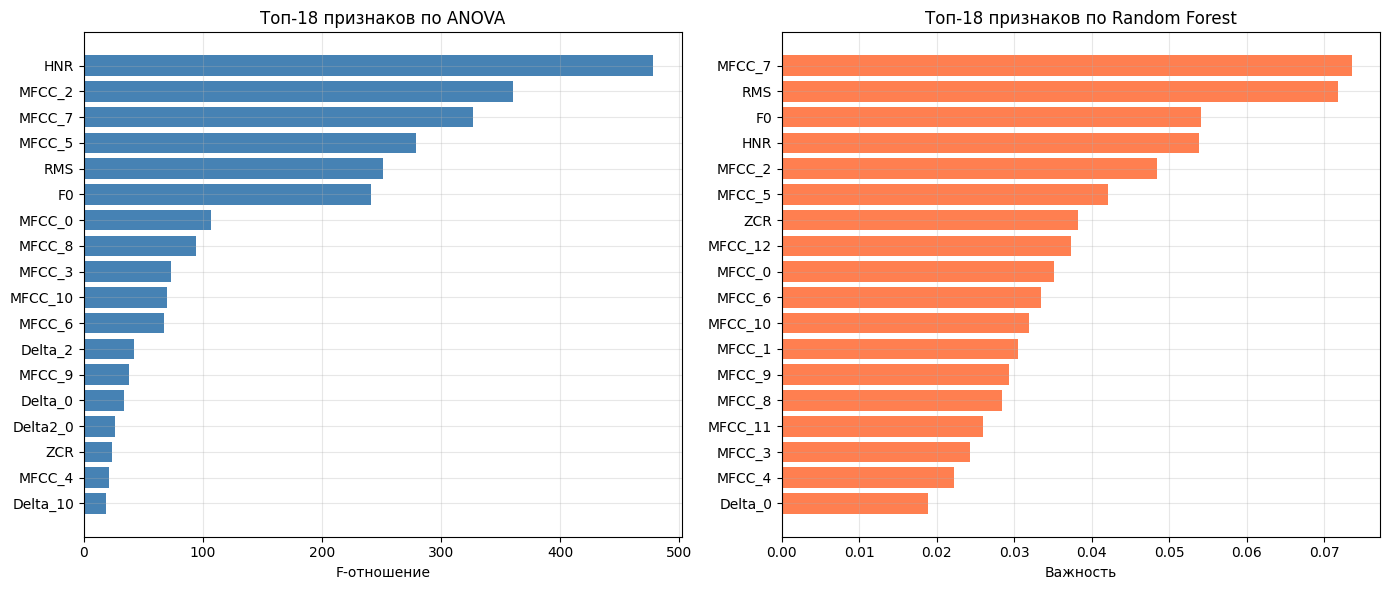

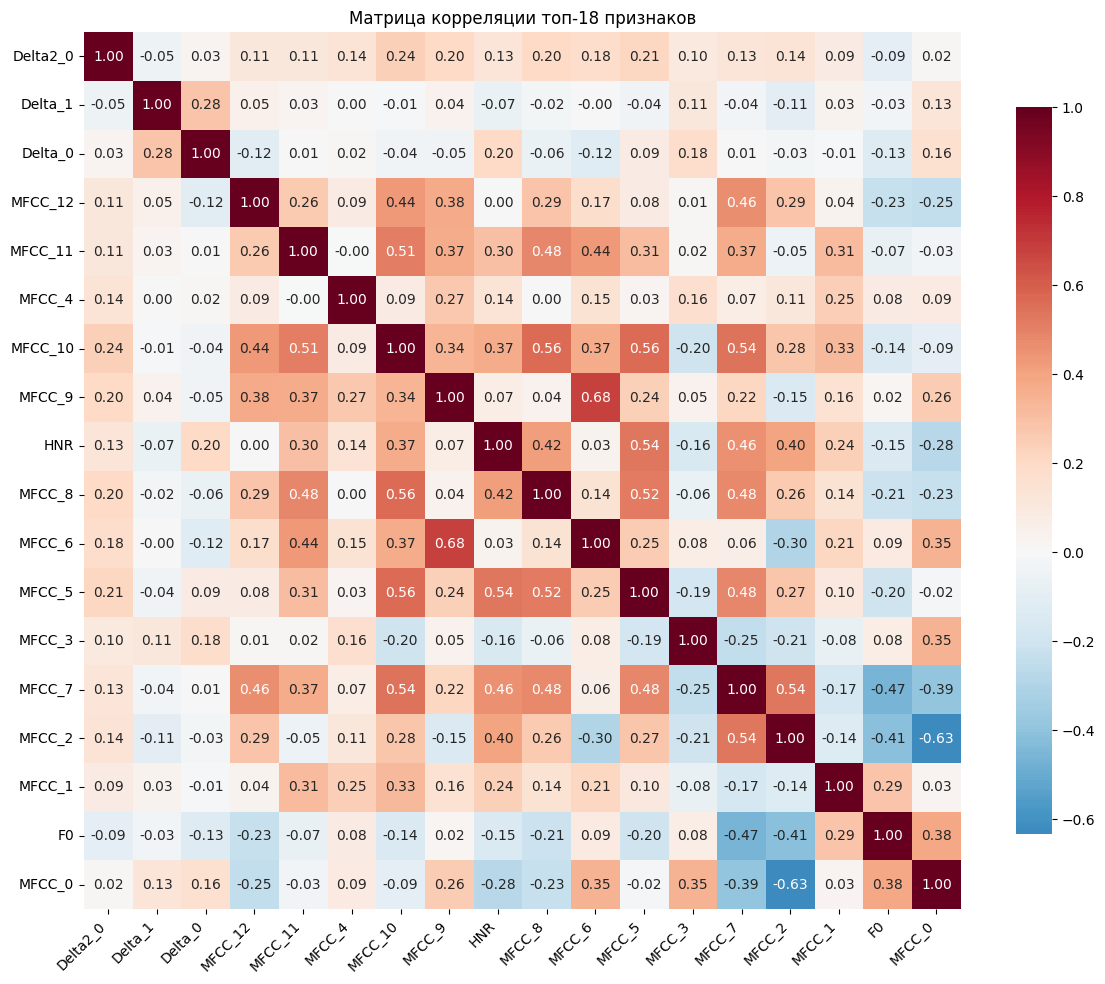


Индексы отобранных признаков: [41, 7, 40, 2, 39, 5, 0, 6, 8, 10, 42, 12, 3, 9, 1, 11, 4, 13]
Количество отобранных признаков: 18

Датасет с 18 признаками сохранён: D:/python_for_data/vkr/fatigue_selected_18_features.npz


In [2]:
TOP_N = 18
DATA_PATH = "D:/python_for_data/vkr/fatigue_all_features.npz"
SELECTED_INDICES_PATH = f"fatigue_selected_{TOP_N}_indices.npy"


temporals, jitters, shimmers, labels = load_full_features(DATA_PATH)

# Анализ признаков
f_scores, rf_importance, feature_names, X_mean = analyze_features(temporals, labels, top_n=25)

# Отбор оптимальных признаков
selected_features = select_optimal_features(temporals, labels, f_scores, rf_importance, 
                                            f_threshold=50, corr_threshold=0.95, 
                                            top_n_combined=TOP_N)

# Визуализация
plot_feature_importance(f_scores, rf_importance, top_n=TOP_N)
plot_correlation_matrix(X_mean, feature_names, top_n=TOP_N)

# Находим индексы отобранных признаков
selected_indices = [feature_names.index(f) for f in selected_features]
np.save(SELECTED_INDICES_PATH, np.array(selected_indices, dtype=np.int32))

print(f"\nИндексы отобранных признаков: {selected_indices}")
print(f"Количество отобранных признаков: {TOP_N}")

# Сохраняем датасет с отобранными признаками
temporals_selected = temporals[:, :, selected_indices]

save_path = f"D:/python_for_data/vkr/fatigue_selected_{TOP_N}_features.npz"
np.savez(
    save_path,
    temporals=temporals_selected,
    labels=labels,
    jitters=jitters,
    shimmers=shimmers
)
print(f"\nДатасет с {len(selected_indices)} признаками сохранён: {save_path}")